# 07 - Fetal QRS detection

Goal: detect fetal QRS complexes from `S5`, then compare the detections with the PhysioNet `.fqrs` reference annotations.

## Why this step is needed

After maternal ECG cancellation, the residual signal `S5` should contain a more visible fetal ECG component. This notebook detects fetal QRS positions and evaluates them against the reference annotations supplied by PhysioNet.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import data_io
import preprocessing
import qrs_detection
import mecg_cancellation
import evaluation
import plotting

# Reload local modules so Jupyter picks up code changes during development.
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(qrs_detection)
importlib.reload(mecg_cancellation)
importlib.reload(evaluation)
importlib.reload(plotting)

from data_io import load_record
from preprocessing import remove_baseline_wander, remove_powerline_interference, upsample_signals
from qrs_detection import detect_maternal_qrs, detect_fetal_qrs
from mecg_cancellation import cancel_maternal_ecg
from evaluation import match_qrs_detections
from plotting import plot_fetal_detection_signal, plot_fetal_qrs_on_channels


## Load the record and rebuild S5

`S5` is rebuilt here so this notebook can run independently. This repeats the previous pipeline: baseline removal, power-line removal, upsampling, maternal QRS detection, and maternal ECG cancellation.

In [2]:
record = load_record('a14')
S1 = record.signals

baseline_result = remove_baseline_wander(
    S1,
    fs=record.fs,
    cutoff_hz=3.0,
    numtaps=1001,
)
S2 = baseline_result.filtered_signals

powerline_result = remove_powerline_interference(
    S2,
    fs=record.fs,
    frequencies_hz=(50.0, 100.0, 150.0),
)
S3 = powerline_result.cleaned_signals

upsampling_result = upsample_signals(
    S3,
    fs=record.fs,
    target_fs=2000.0,
)
S4 = upsampling_result.upsampled_signals
fs_s5 = upsampling_result.target_fs
duration_s = S4.shape[0] / fs_s5

mqrs_result = detect_maternal_qrs(
    S4,
    fs=fs_s5,
    max_heart_rate_bpm=140.0,
)

mecg_result = cancel_maternal_ecg(
    S4,
    mqrs_samples=mqrs_result.mqrs_samples,
    fs=fs_s5,
    preceding_beats=10,
    before_s=0.25,
    after_s=0.45,
    qrs_half_width_s=0.05,
)
S5 = mecg_result.cancelled_signals

print(f'Record: {record.name}')
print(f'S5 shape: {S5.shape}')
print(f'S5 sampling frequency: {fs_s5:.0f} Hz')
print(f'S5 duration: {duration_s:.2f} s')


Record: a14
S5 shape: (120000, 4)
S5 sampling frequency: 2000 Hz
S5 duration: 60.00 s


## Prepare the fetal reference annotations

PhysioNet provides fetal QRS reference annotations in the `.fqrs` file. The original reference is at 1000 Hz, while `S5` is at 2000 Hz, so we convert the reference samples to the `S5` sampling grid.

In [3]:
reference_fqrs_s5 = np.round(record.fqrs_reference * fs_s5 / record.fs).astype(int)
reference_fqrs_times = reference_fqrs_s5 / fs_s5

print(f'Reference FQRS count: {len(reference_fqrs_s5)}')
print(f'First five reference FQRS times: {np.round(reference_fqrs_times[:5], 4)} s')


Reference FQRS count: 123
First five reference FQRS times: [0.157 0.608 1.056 1.516 1.976] s


## Detect fetal QRS complexes

The detector filters `S5`, calculates QRS-like energy in each channel, combines the channels, and searches for peaks. The detected peaks are the fetal QRS candidates.

In [4]:
fqrs_result = detect_fetal_qrs(
    S5,
    fs=fs_s5,
    low_hz=10.0,
    high_hz=60.0,
    integration_window_s=0.035,
    threshold_percentile=85.0,
    min_distance_s=0.25,
    min_prominence=0.2,
)
detected_fqrs = fqrs_result.fqrs_samples
detected_fqrs_times = detected_fqrs / fs_s5

print(f'Detected FQRS: {len(detected_fqrs)}')
print(f'First five detected FQRS times: {np.round(detected_fqrs_times[:5], 4)} s')
print(f'Detection threshold: {fqrs_result.threshold:.3f}')


Detected FQRS: 124
First five detected FQRS times: [0.2725 0.612  0.898  1.5335 2.1645] s
Detection threshold: 0.440


## Evaluate detection performance

A detected fetal beat is counted as correct if it falls within 50 ms of a reference fetal beat. This gives true positives, false positives, false negatives, sensitivity, positive predictive value, and F1-score. We also calculate the mean fetal R-R interval and the estimated fetal heart rate from the detected fetal beats.

In [5]:
performance = match_qrs_detections(
    detected_fqrs,
    reference_fqrs_s5,
    fs=fs_s5,
    tolerance_s=0.05,
)

summary = pd.DataFrame([
    {
        'record': record.name,
        'reference_fqrs': len(reference_fqrs_s5),
        'detected_fqrs': len(detected_fqrs),
        'true_positives': performance.true_positives,
        'false_positives': performance.false_positives,
        'false_negatives': performance.false_negatives,
        'sensitivity': performance.sensitivity,
        'positive_predictive_value': performance.positive_predictive_value,
        'f1_score': performance.f1_score,
        'mean_abs_error_ms': performance.mean_abs_error_ms,
        'tolerance_ms': performance.tolerance_s * 1000,
    }
])

detected_rr_s = np.diff(detected_fqrs_times)
fhr_summary = pd.DataFrame([
    {
        'record': record.name,
        'detected_fqrs': len(detected_fqrs),
        'mean_rr_ms': np.mean(detected_rr_s) * 1000,
        'median_rr_ms': np.median(detected_rr_s) * 1000,
        'estimated_fhr_bpm': 60 / np.mean(detected_rr_s),
    }
])

display(summary)
fhr_summary


,record,reference_fqrs,detected_fqrs,true_positives,false_positives,false_negatives,sensitivity,positive_predictive_value,f1_score,mean_abs_error_ms,tolerance_ms
0,a14,123,124,111,13,12,0.902439,0.895161,0.898785,6.396396,50.0


,record,detected_fqrs,mean_rr_ms,median_rr_ms,estimated_fhr_bpm
0,a14,124,485.353659,483.0,123.621197


## Save detections, performance, and FHR estimate

The detected FQRS positions are saved as sample indices in `S5` and as seconds. The performance summary and the fetal heart-rate estimate are saved separately.

In [6]:
results_dir = PROJECT_ROOT / 'results' / 'notebook07'
results_dir.mkdir(parents=True, exist_ok=True)

fqrs_table = pd.DataFrame({
    'sample_s5': detected_fqrs.astype(int),
    'time_s': detected_fqrs_times,
})
fqrs_path = results_dir / 'a14_fqrs_detected.csv'
performance_path = results_dir / 'a14_fqrs_performance.csv'
fhr_path = results_dir / 'a14_fhr_summary.csv'
fqrs_table.to_csv(fqrs_path, index=False)
summary.to_csv(performance_path, index=False)
fhr_summary.to_csv(fhr_path, index=False)
fqrs_table.head()


,sample_s5,time_s
0,545,0.2725
1,1224,0.6120
2,1796,0.8980
3,3067,1.5335
4,4329,2.1645


## Detection signal plot

This plot shows the signal used by the detector. Black crosses are detected FQRS positions. Red circles are reference FQRS positions.

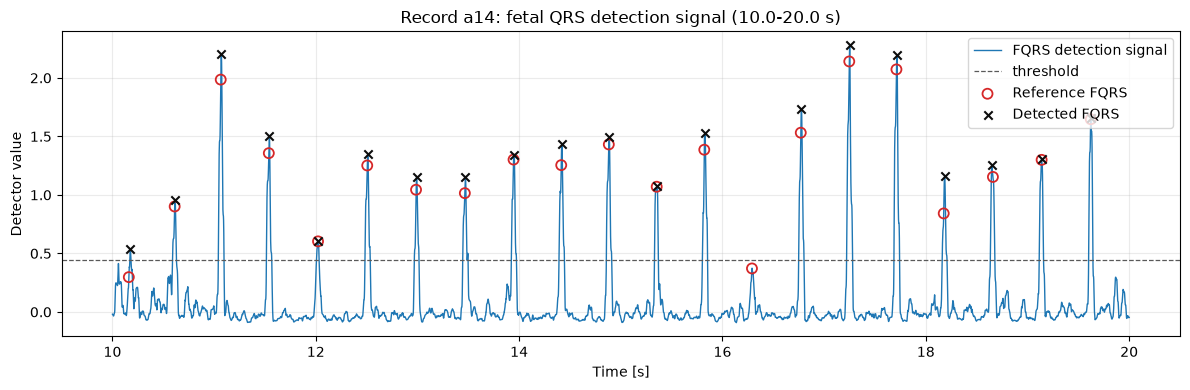

In [7]:
fig, ax = plot_fetal_detection_signal(
    record.name,
    fqrs_result.detection_signal,
    detected_fqrs,
    reference_fqrs_s5,
    fs=fs_s5,
    seconds=(10, 20),
    threshold=fqrs_result.threshold,
    save_path=PROJECT_ROOT / 'figures' / 'notebook07' / 'a14_fqrs_detection_signal_10_20s.png',
)
plt.show()


## Detected and reference FQRS on S5 channels

These plots overlay detected fetal beats and reference fetal beats on the residual `S5` channels.

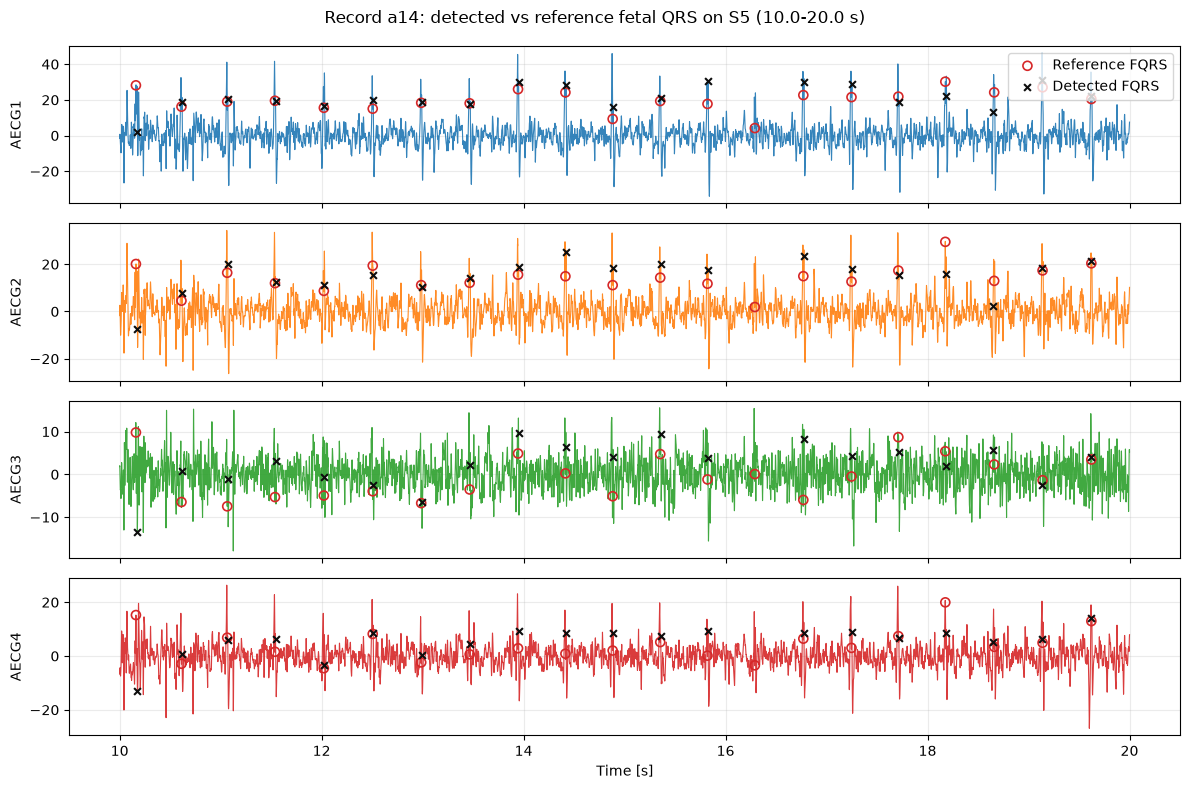

In [8]:
fig, axes = plot_fetal_qrs_on_channels(
    record,
    S5,
    fs=fs_s5,
    detected_fqrs_samples=detected_fqrs,
    reference_fqrs_samples=reference_fqrs_s5,
    seconds=(10, 20),
    save_path=PROJECT_ROOT / 'figures' / 'notebook07' / 'a14_fqrs_on_s5_10_20s.png',
)
plt.show()


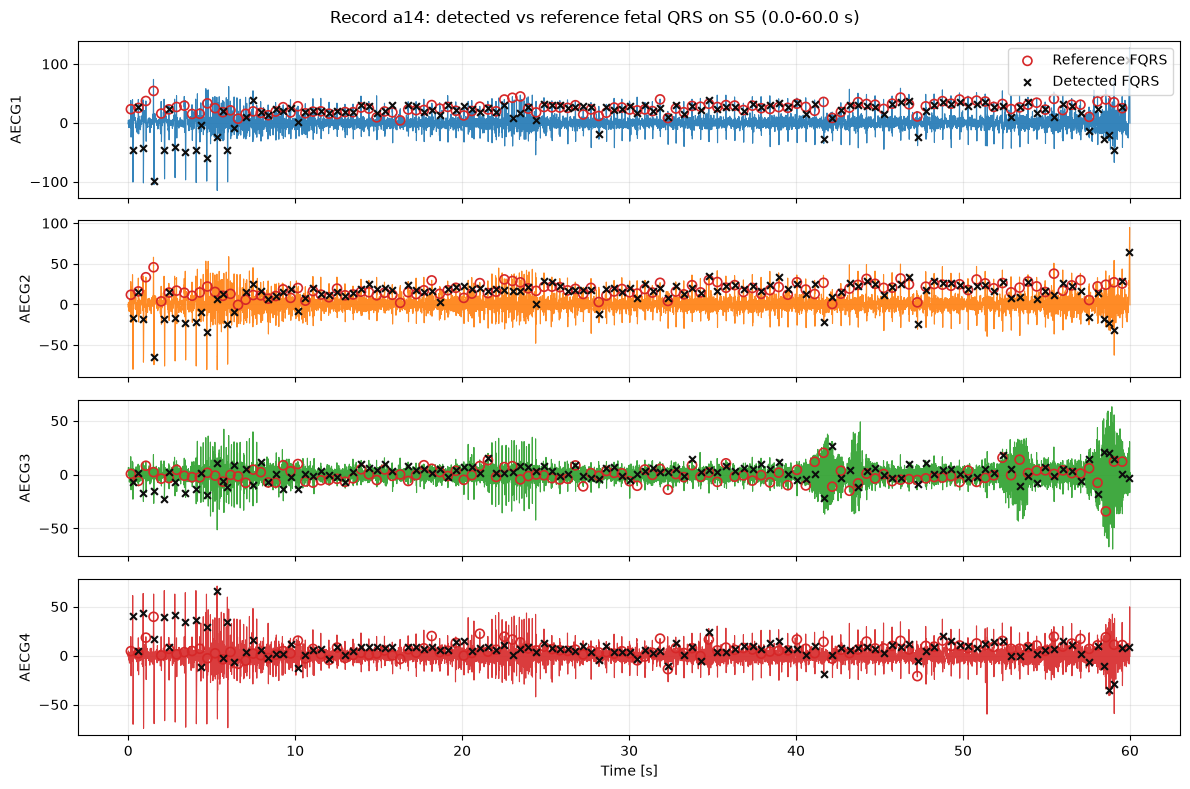

In [9]:
fig, axes = plot_fetal_qrs_on_channels(
    record,
    S5,
    fs=fs_s5,
    detected_fqrs_samples=detected_fqrs,
    reference_fqrs_samples=reference_fqrs_s5,
    seconds=(0, duration_s),
    save_path=PROJECT_ROOT / 'figures' / 'notebook07' / 'a14_fqrs_on_s5_full.png',
)
plt.show()


## Output of this step

The output is the list of fetal QRS positions detected from `S5`, plus a performance comparison with the PhysioNet fetal reference annotations. The next project step is to use the detected fetal QRS positions to build the average fetal ECG waveform `S6`.